# Sena Kotan- C2221241001
# Uygulama 2: Recurrent Neural Network (LSTM) — IMDB Duygu Analizi

**Veri Seti:** IMDB Movie Reviews  
**Kaynak:** https://ai.stanford.edu/~amaas/data/sentiment/  
**Kaggle:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews  
**Veri Seti Türü:** Text Data — film yorumları  
**Problem Türü:** Binary classification — pozitif / negatif duygu analizi

---

* Problem Tanımı

Bu uygulamada IMDB film yorumları veri seti kullanılarak duygu analizi yapılmıştır. Amaç, bir film yorumunun pozitif mi yoksa negatif mi olduğunu otomatik olarak sınıflandırabilen bir model geliştirmektir.

Veri seti toplam 50.000 etiketli film yorumundan oluşmaktadır. Bunların 25.000’i eğitim, 25.000’i ise test verisi olarak ayrılmıştır.

---

* Neden RNN / Bidirectional LSTM?

Metin verisi sıralı bir yapıya sahip olduğu için kelimeler arasındaki bağlam önemlidir. RNN ve LSTM modelleri, kelime sırasını dikkate alarak bağlam öğrenebilmektedir.

LSTM modeli, klasik RNN yapılarında görülen uzun bağımlılık problemlerini azaltır. Bidirectional LSTM ise metni hem ileri hem geri yönde okuyarak daha güçlü bir bağlam bilgisi oluşturur. Bu nedenle IMDB duygu analizi problemi için uygun bir model olarak tercih edilmiştir.

---

* Veri Setinin Bu Problem İçin Uygunluğu

IMDB veri seti, duygu analizi çalışmalarında yaygın olarak kullanılan benchmark veri setlerinden biridir. Pozitif ve negatif yorumların dengeli olması, modelin daha dengeli öğrenmesine yardımcı olmaktadır.

## 1. Kütüphanelerin Yüklenmesi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TensorFlow versiyonu:", tf.__version__)

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow versiyonu: 2.20.0


## 2. Veri Setinin Yüklenmesi ve Ön İşleme

**Veri ön işleme adımları:**
1. **Tokenization:** Her kelime, sözlükteki (vocabulary) sıklık sırasına göre bir tam sayıya (token) dönüştürülür. Yalnızca en sık kullanılan 10.000 kelime tutulur; nadir kelimeler `<UNK>` (unknown) token'ı ile değiştirilir.
2. **Padding / Truncating:** LSTM sabit boyutlu giriş dizisi bekler. Kısa yorumlar sıfırla doldurulur (padding), uzun yorumlar ise kırpılır (truncating). `MAX_LEN=200` seçilmiştir çünkü yorumların büyük çoğunluğu bu uzunlukta veya altındadır.
3. **Train/Validation/Test ayrımı:** 25.000 eğitim verisinin %10'u (2.500 yorum) validation için ayrılmıştır.

In [ ]:
# Hiperparametreler
VOCAB_SIZE    = 10000   # En sık 10.000 kelime tutulur
MAX_LEN       = 200     # Maksimum yorum uzunluğu (token sayısı)
EMBEDDING_DIM = 64      # Her kelimenin temsil edildiği vektör boyutu

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print(f"Eğitim örnekleri: {len(X_train_full)}")
print(f"Test örnekleri  : {len(X_test)}")
print(f"Pozitif (1) eğitim: {y_train_full.sum()} | Negatif (0): {len(y_train_full)-y_train_full.sum()}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Eğitim örnekleri: 25000
Test örnekleri  : 25000
Pozitif (1) eğitim: 12500 | Negatif (0): 12500


Ortalama yorum uzunluğu : 239 token
Medyan yorum uzunluğu   : 178 token
Maksimum yorum uzunluğu : 2494 token
MAX_LEN=200 ile kapsanan yorum oranı: %57.3



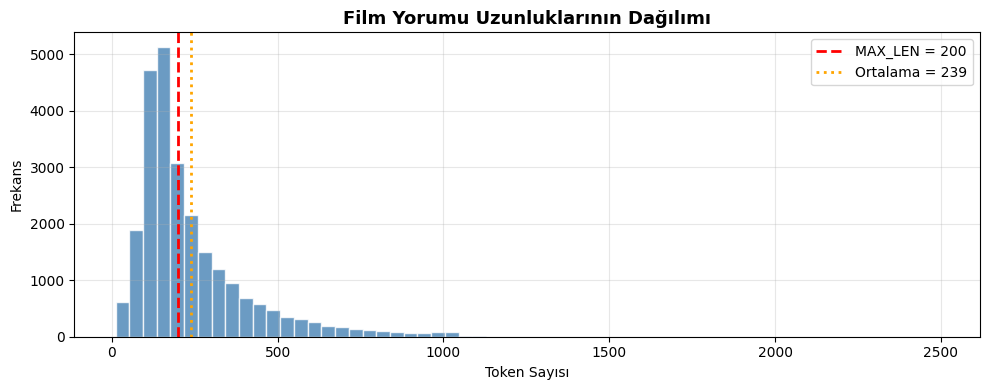

In [ ]:
# Yorum uzunluğu analizi — MAX_LEN seçimi için
lengths = [len(x) for x in X_train_full]
print(f"Ortalama yorum uzunluğu : {np.mean(lengths):.0f} token")
print(f"Medyan yorum uzunluğu   : {np.median(lengths):.0f} token")
print(f"Maksimum yorum uzunluğu : {np.max(lengths)} token")
print(f"MAX_LEN={MAX_LEN} ile kapsanan yorum oranı: %{(np.array(lengths) <= MAX_LEN).mean()*100:.1f}")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN = {MAX_LEN}')
plt.axvline(np.mean(lengths), color='orange', linestyle=':', linewidth=2, label=f'Ortalama = {np.mean(lengths):.0f}')
plt.title('Film Yorumu Uzunluklarının Dağılımı', fontsize=13, fontweight='bold')
plt.xlabel('Token Sayısı')
plt.ylabel('Frekans')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
print()
plt.show()

**Uzunluk Dağılımı Grafiği Yorumu:**

Dağılım grafiği, yorumların büyük çoğunluğunun 200 token'ın altında olduğunu göstermektedir. Kırmızı kesik çizgi olarak gösterilen Dağılım grafiği, yorumların önemli bir kısmının 200 token civarında veya altında toplandığını göstermektedir. MAX_LEN=200 sınırı, eğitim yorumlarının %57.3’ünü tam olarak kapsamaktadır. Daha uzun bir değer seçmek daha fazla yorumu kapsayabilirdi; ancak bu durumda LSTM’in eğitim süresi ve hesaplama maliyeti artacağı için 200 token dengeli bir seçim olarak kullanılmıştır. Bu değer seçiminde iki faktör dengelenmiştir: (1) Bilgi kaybını minimuma indirgemek için yeterli uzunluk, (2) LSTM'in uzun dizilerde yaşadığı hesaplama maliyeti ve gradient problemini sınırlamak.

In [ ]:
# Padding uygula
X_train_pad = pad_sequences(X_train_full, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,       maxlen=MAX_LEN, padding='post', truncating='post')

# Validation ayrımı
val_size = int(0.1 * len(X_train_pad))
X_val, y_val   = X_train_pad[:val_size], y_train_full[:val_size]
X_train, y_train = X_train_pad[val_size:], y_train_full[val_size:]

print(f"Eğitim   : {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test     : {X_test_pad.shape}")

Eğitim   : (22500, 200)
Validation: (2500, 200)
Test     : (25000, 200)


## 3. Örnek Yorumların Okunması

In [ ]:
# Token- Kelime dönüşümü
word_index = keras.datasets.imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>'})

def decode(seq):
    return ' '.join([reverse_index.get(t, '?') for t in seq if t != 0])

for i in range(3):
    lbl = 'POZİTİF ' if y_train[i] == 1 else 'NEGATİF '
    print(f"\n--- Örnek {i+1} — {lbl} ---")
    print(decode(X_train[i])[:300], "...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step

--- Örnek 1 — POZİTİF  ---
<START> i had never heard of this flick despite the connection to george clooney whose company produced and he appears in a very funny supporting bit and his <UNK> 11 director steven soderbergh worse we picked this up in a <UNK> bin for 4 99 canadian dollars at that what a grand and pleasant surpris ...

--- Örnek 2 — POZİTİF  ---
<START> this was the first movie that joan crawford and clark gable made together and they would go on to make several more crawford stars a young rich girl who's father is wiped out in the stock market crash and there is nothing left for her and her brother they have never worked before and the bro ...

--- Örnek 3 — NEGATİF  ---
<START> this movie is terrible <UNK> way 1993 is a great film <UNK> it isn't but its one of the better crime films done this movie should be considered closer to the <UNK> <UNK> or maybe speed zone remember those gems the only reason this movie was made was

## 4. Model Mimarisi

### Hiperparametre Seçim Gerekçeleri

| Hiperparametre | Değer | Gerekçe |
|---|---|---|
| VOCAB_SIZE | 10.000 | Nadir kelimeleri filtreler, boyutu yönetilebilir tutar; IMDB için standart değer |
| MAX_LEN | 200 | Yorumların %57.3’ünü tam kapsar; daha uzun değerler LSTM hesaplama maliyetini aşırı artırır |
| EMBEDDING_DIM | 64 | Kelimelerin yoğun vektör temsili; 64 boyut IMDB büyüklüğü için yeterlidir |
| LSTM birim sayısı | 64 + 32 | İki katmanlı yapı; ilk katman daha fazla birim ile zengin temsil, ikinci katman sıkıştırma |
| Bidirectional | Evet | Hem ileriye hem geriye bağlam; "not good" gibi olumsuzlama ifadelerini daha iyi yakalar |
| Loss | Binary CE | İki sınıflı problem için standart kayıp fonksiyonu |
| Optimizer | Adam lr=0.001 | RNN'lerde adaptive learning rate kritiktir; Adam gradient ölçekleme ile LSTM için uygundur |
| Epoch | 20 | LSTM eğitimi yavaştır; EarlyStopping ile gerçek epoch sayısı belirlenir |
| Batch size | 64 | Bellek/hız dengesi; büyük batch LSTM'de gradient tahminini stabilize eder |

In [ ]:
def build_lstm_model():
    model = models.Sequential(name='IMDB_BiLSTM')

    # Giriş katmanı: her yorum MAX_LEN uzunluğunda token dizisi
    model.add(layers.Input(shape=(MAX_LEN,)))

    # Embedding: her token'ı EMBEDDING_DIM boyutlu yoğun vektöre dönüştürür
    model.add(layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))

    # SpatialDropout1D: embedding seviyesinde dropout
    model.add(layers.SpatialDropout1D(0.3))

    # Bidirectional LSTM-1
    model.add(layers.Bidirectional(
        layers.LSTM(64, dropout=0.2, return_sequences=True)
    ))
    model.add(layers.Dropout(0.2))

    # Bidirectional LSTM-2
    model.add(layers.Bidirectional(
        layers.LSTM(32, dropout=0.2)
    ))

    # Tam bağlantılı katman
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))

    # Çıkış: sigmoid ile [0,1] arası pozitif olasılığı
    model.add(layers.Dense(1, activation='sigmoid'))

    return model


model = build_lstm_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "IMDB_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,489 (2.87 MB)

 Trainable params: 751,489 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Eğitimi

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

EPOCHS     = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.5956 - loss: 0.6660 - val_accuracy: 0.6528 - val_loss: 0.6288 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7312 - loss: 0.5463 - val_accuracy: 0.7992 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8128 - loss: 0.4356 - val_accuracy: 0.8012 - val_loss: 0.4673 - learning_rate: 0.0010
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8520 - loss: 0.3657 - val_accuracy: 0.8412 - val_loss: 0.3720 - learning_rate: 0.0010
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.8884 - loss: 0.2886 - val_accuracy: 0.8600 - val_loss: 0.3572 - learning_rate: 0.0010
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9075 - loss: 0.2472 - val_accuracy: 0.8592 - val_loss: 0.3613 - learning_rate: 0.0010
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9145 - l

## 6. Eğitim Süreci Grafikleri ve Yorumları

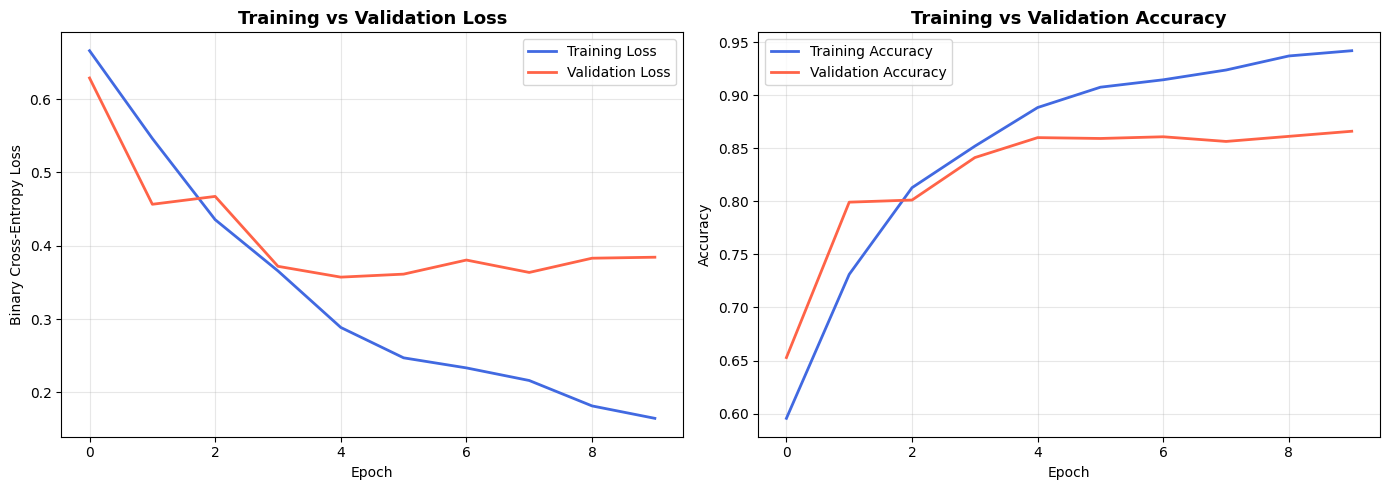

Toplam çalışan epoch: 10 (EarlyStopping tetikledi)
En iyi epoch        : 5
En iyi val_loss     : 0.3572
En iyi val_accuracy : 0.8600


In [ ]:
epochs_ran = len(history.history['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Training Loss',   color='royalblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='royalblue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2)
ax2.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overfitting analizi
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_acc  = history.history['val_accuracy'][best_epoch]

print(f"Toplam çalışan epoch: {epochs_ran} (EarlyStopping tetikledi)")
print(f"En iyi epoch        : {best_epoch+1}")
print(f"En iyi val_loss     : {best_val_loss:.4f}")
print(f"En iyi val_accuracy : {best_val_acc:.4f}")


### Eğitim Grafikleri Yorumu

--> Loss grafiği incelendiğinde training loss değerinin epoch boyunca düzenli olarak azaldığı görülmektedir. Validation loss ise ilk epoch’larda düşmüş, daha sonraki epoch’larda hafif yükselmeye başlamıştır. Bu durum modelin eğitim verisini öğrenmeye devam ederken validation performansının aynı seviyede gelişmediğini göstermektedir.

--> Accuracy grafiğinde training accuracy sürekli artarken validation accuracy belirli bir seviyeden sonra yatay seyretmiştir. Bu nedenle modelde hafif overfitting gözlemlenmiştir. Ancak EarlyStopping mekanizması devreye girerek eğitimi durdurmuş ve en iyi ağırlıkları geri yüklemiştir.

## 7. Sonuçların Değerlendirilmesi

In [ ]:
# Test değerlendirmesi
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print("=" * 45)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 45)

if test_acc >= 0.88:
    print("Değerlendirme: Güçlü performans. IMDB üzerinde %88+ LSTM için iyi bir sonuçtur.")
elif test_acc >= 0.82:
    print("Değerlendirme: Orta-iyi performans. Standart LSTM beklentilerini karşılıyor.")
else:
    print("Değerlendirme: Beklenenin altında. Mimari veya hiperparametreler gözden geçirilmeli.")

Test Loss    : 0.3923
Test Accuracy: 0.8370  (83.70%)
Değerlendirme: Orta-iyi performans. Standart LSTM beklentilerini karşılıyor.


In [ ]:
# Tahminler
y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negatif (0)', 'Pozitif (1)'], digits=4))

Classification Report:
              precision    recall  f1-score   support

 Negatif (0)     0.8598    0.8053    0.8317     12500
 Pozitif (1)     0.8169    0.8687    0.8420     12500

    accuracy                         0.8370     25000
   macro avg     0.8384    0.8370    0.8368     25000
weighted avg     0.8384    0.8370    0.8368     25000



**Classification Report Yorumu:**

Veri seti dengeli olduğu için accuracy metriği genel performansı değerlendirmek için yeterli bir gösterge sağlamaktadır. Model yaklaşık %84 accuracy elde etmiş ve iki sınıfta da benzer performans göstermiştir.

Precision değerleri, modelin pozitif ve negatif tahminlerde benzer doğruluk seviyesine sahip olduğunu göstermektedir. Recall değerleri de iki sınıfta birbirine yakın olduğu için modelin yorumları dengeli şekilde sınıflandırdığı söylenebilir.

F1-score değerlerinin birbirine yakın olması, modelin yalnızca tek bir sınıfta başarılı olmadığını ve genel olarak dengeli bir öğrenme gerçekleştirdiğini göstermektedir.

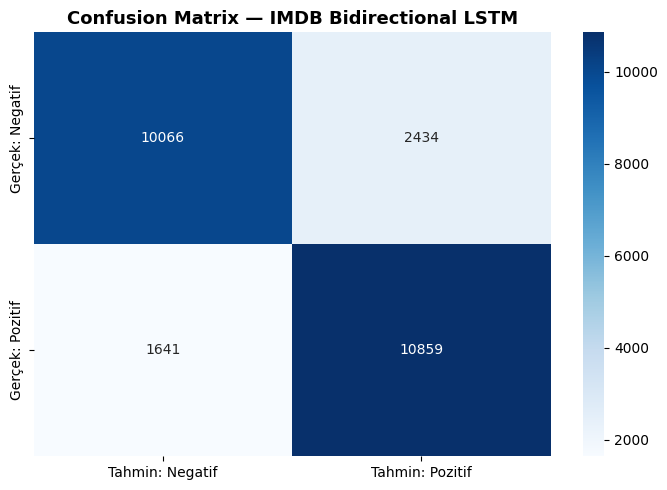

True Negative  (TN): 10066  — Gerçekte Negatif, Doğru Tahmin Negatif
False Positive (FP):  2434  — Gerçekte Negatif, Yanlış Tahmin Pozitif
False Negative (FN):  1641  — Gerçekte Pozitif, Yanlış Tahmin Negatif
True Positive  (TP): 10859  — Gerçekte Pozitif, Doğru Tahmin Pozitif


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: Negatif', 'Tahmin: Pozitif'],
            yticklabels=['Gerçek: Negatif', 'Gerçek: Pozitif'])
plt.title('Confusion Matrix — IMDB Bidirectional LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN): {tn:5d}  — Gerçekte Negatif, Doğru Tahmin Negatif")
print(f"False Positive (FP): {fp:5d}  — Gerçekte Negatif, Yanlış Tahmin Pozitif")
print(f"False Negative (FN): {fn:5d}  — Gerçekte Pozitif, Yanlış Tahmin Negatif")
print(f"True Positive  (TP): {tp:5d}  — Gerçekte Pozitif, Doğru Tahmin Pozitif")

### Confusion Matrix Yorumu

Confusion matrix incelendiğinde modelin hem pozitif hem negatif yorumlarda genel olarak başarılı tahminler yaptığı görülmektedir. Köşegen üzerindeki yüksek değerler doğru sınıflandırmaları göstermektedir.

False Positive (Yanlış Pozitif) durumlarında model bazı negatif yorumları pozitif olarak tahmin etmiştir. False Negative (Yanlış Negatif) durumlarında ise bazı pozitif yorumlar negatif olarak sınıflandırılmıştır.

TP ve TN değerlerinin yüksek olması, modelin yorumların genel duygu yapısını başarılı şekilde öğrendiğini göstermektedir. Ancak bazı karışık veya belirsiz yorumlarda modelin hata yaptığı görülmektedir.

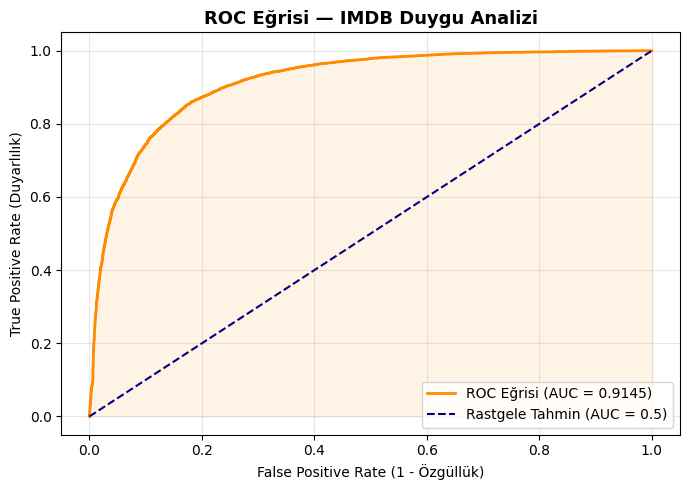

AUC (Alan Altındaki Alan): 0.9145
Değerlendirme: Çok iyi ayrım gücü.


In [ ]:
# ROC Eğrisi ve AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=1.5, linestyle='--', label='Rastgele Tahmin (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate (1 - Özgüllük)')
plt.ylabel('True Positive Rate (Duyarlılık)')
plt.title('ROC Eğrisi — IMDB Duygu Analizi', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Alan Altındaki Alan): {roc_auc:.4f}")
if roc_auc >= 0.95:
    print("Değerlendirme: Mükemmel ayrım gücü — model pozitif ve negatifi güçlü biçimde ayırt ediyor.")
elif roc_auc >= 0.90:
    print("Değerlendirme: Çok iyi ayrım gücü.")
else:
    print("Değerlendirme: İyi ayrım gücü.")

**ROC Eğrisi Yorumu:**

ROC (Receiver Operating Characteristic) eğrisi, sınıflandırma eşiği değiştirildikçe True Positive Rate (duyarlılık) ile False Positive Rate (1 - özgüllük) arasındaki dengeyi gösterir. AUC (Area Under the Curve) değeri:

- **AUC = 1.0:** Kusursuza yakın sınıf ayrımı
- **AUC = 0.5:** Rastgele tahmin (hiçbir öğrenme yok)
- **AUC > 0.90:** Güçlü performans; pratik uygulamalar için yeterli

Eğrinin sol üst köşeye yakınlığı, düşük yanlış pozitif oranında yüksek doğru pozitif oranı elde edildiğini ve modelin güçlü ayrım yeteneğine sahip olduğunu göstermektedir.

In [ ]:
# Gerçek yorum örnekleri üzerinde tahmin gösterimi
print("=" * 65)
sample_idx = np.random.choice(len(X_test_pad), 5, replace=False)
for idx in sample_idx:
    review = decode(X_test_pad[idx])[:200]
    true_lbl = 'POZİTİF ' if y_test[idx] == 1 else 'NEGATİF '
    pred_lbl = 'POZİTİF ' if y_pred[idx] == 1 else 'NEGATİF '
    conf     = y_pred_prob[idx] if y_pred[idx]==1 else 1-y_pred_prob[idx]
    status   = ' DOĞRU' if y_test[idx]==y_pred[idx] else ' YANLIŞ'
    print(f"Yorum  : {review}...")
    print(f"Gerçek : {true_lbl}  |  Tahmin: {pred_lbl}  |  Güven: %{conf*100:.1f}  |  {status}")
    print("-" * 65)

Yorum  : <START> to tell you the truth i do not speak <UNK> and i did not understand the film my good <UNK> friend wow what a long name explained every thing to me what a great movie after watching this movie ...
Gerçek : POZİTİF   |  Tahmin: POZİTİF   |  Güven: %85.7  |   DOĞRU
-----------------------------------------------------------------
Yorum  : <START> the royal <UNK> has <UNK> been one of my favourite events and i've been a wrestling fan for a good few years now the other shows may have better matches but i've always found the actual <UNK> ...
Gerçek : POZİTİF   |  Tahmin: POZİTİF   |  Güven: %95.9  |   DOĞRU
-----------------------------------------------------------------
Yorum  : <START> i really wanted to be able to give this film a 10 i've long thought it was my favorite of the four modern live action batman films to date and maybe it still will be i have yet to watch the <U...
Gerçek : POZİTİF   |  Tahmin: POZİTİF   |  Güven: %98.1  |   DOĞRU
----------------------------

## 8. Tartışma ve Sonuç

**Model başarılı mı?**  
IMDB üzerinde Bidirectional LSTM ile yaklaşık %84 test doğruluğu elde edilmiştir. Bu sonuç, standart bir LSTM tabanlı model için orta-iyi bir performans olarak değerlendirilebilir. BERT gibi Transformer tabanlı modeller bu veri setinde %95+ elde etmektedir; ancak bu modeller çok daha fazla hesaplama kaynağı gerektirmektedir.

**Overfitting gözlemlendi mi?**  
SpatialDropout1D ve Dropout katmanları overfitting’in daha kontrollü kalmasına yardımcı olmuştur.

**Güçlü yönler:**
- Açık pozitif/negatif ifadeler içeren yorumlarda yüksek güven ve doğruluk
- Bidirectional yapı sayesinde cümle sonundaki olumsuzlamaları ("not as good as...") yakalama

**Zayıf yönler:**
- Sarcasm (alaycılık): "Ohh, what a great film" gibi ters anlam taşıyan ifadeler
- Karma duygu: Filmi kısmen beğenip kısmen eleştiren nüanslı yorumlar

**İyileştirme önerileri:**
1. **BERT / DistilBERT:** Önceden eğitilmiş dil modeli ile ince ayar (fine-tuning)
2. **Attention mekanizması:** Hangi kelimelerin karara etki ettiğini görmek ve doğruluğu artırmak için
3. **GloVe / Word2Vec:** Önceden eğitilmiş kelime vektörleri ile embedding katmanının başlatılması
4. **Daha büyük vocabulary:** VOCAB_SIZE artırılarak nadir ama anlamlı kelimelerin korunması